## Customer Segmentation Report
A mid-sized e-commerce company wants to optimize marketing spend. I analyzed their sales and customer data to identify behavioral segments for personalized campaigns. 
Customer segmentation helps businesses identify distinct groups of customers who exhibit similar characteristics or purchasing behavior. Segmenting customers enables organizations to personalize marketing strategies, optimize customer engagement, and improve retention.

This report presents a complete end-to-end analysis for segmenting customers using the K-Means clustering algorithm. It leverages numerical attributes such as Recency, Frequency, and Monetary Value (RFM) to uncover customer groups and visualize key insights through snake plots and heatmaps.

## 1. Loading packages and Inspecting the Data
We begin by importing the essential Python libraries for data manipulation, visualization, and clustering. After loading the dataset, we perform an initial inspection to understand its structure, data types, and missing values using pandas.info().

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set visualization style
sns.set_style("darkgrid")

# Load the data and replace with your CSV file path
df = pd.read_csv(r"C:\Users\mishi\Downloads\customer_data.csv")


# Preview the data
df


,CustomerID,Recency,Frequency,MonetaryValue
0,12747,3,25,948.70
1,12748,1,888,7046.16
2,12749,4,37,813.45
3,12820,4,17,268.02
4,12822,71,9,146.15
...,...,...,...,...
3638,18280,278,2,38.70
3639,18281,181,2,31.80
3640,18282,8,2,30.70
3641,18283,4,152,432.93


## 2. Exploring the Data
To prepare for clustering, we focus only on the numerical variables that capture customer purchasing patterns. Since CustomerID is an identifier, it is excluded from analysis.


Descriptive statistics provide an overview of the data distribution, helping identify potential skewness, variation, or outliers.
Because K-Means assumes balanced variance and relatively symmetrical distributions, this step ensures our data aligns with those assumptions.

In [12]:
# Select columns for clustering
columns_for_clustering = ["Recency", "Frequency", "MonetaryValue"]

# Create new DataFrame with clustering variables
df_features = df[columns_for_clustering]

# Print a summary of descriptive statistics
df_features.describe()

,Recency,Frequency,MonetaryValue
count,3643.00000,3643.000000,3643.000000
mean,90.43563,18.714247,370.694387
std,94.44651,43.754468,1347.443451
min,1.00000,1.000000,0.650000
25%,19.00000,4.000000,58.705000
50%,51.00000,9.000000,136.370000
75%,139.00000,21.000000,334.350000
max,365.00000,1497.000000,48060.350000


The [`facetgrid()`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) function from `seaborn` creates a grid of histograms of the data to be clustered.  It serves as a further exploration of the data to determine its skew and whether it needs transformation. To further examine distribution shapes, histograms are generated for each selected feature:

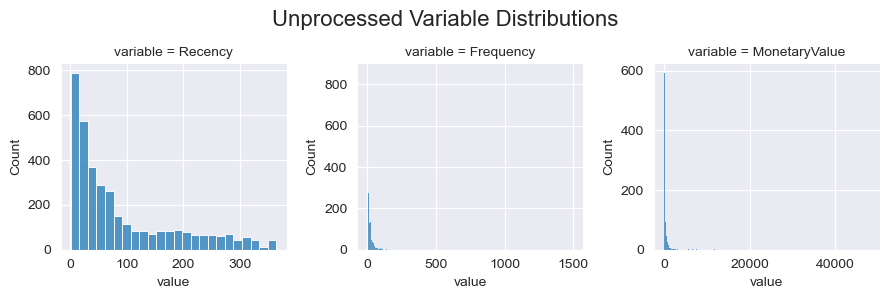

In [14]:
g = sns.FacetGrid(
    df_features.melt(), 
    col="variable",  # Split on the 'variable' column created by reformating
    sharey=False,  # Turn off shared y-axis
    sharex=False,  # Turn off shared x-axis
)
# Apply a histogram to the facet grid
g.map(sns.histplot, "value")  
g.fig.subplots_adjust(top=0.8)
# Create a title
g.fig.suptitle("Unprocessed Variable Distributions", fontsize=16)
plt.show()

Before proceeding, it is crucial to ensure that all columns selected for clustering are numeric. The following code iterates through the reduced DataFrame and checks whether each column is numeric. If it returns `True`, then you can proceed with the pre-processing.

In [ ]:
all([pd.api.types.is_numeric_dtype(df_features[col]) for col in columns_for_clustering])

## 3. Data Preprocessing
If any variable is significantly skewed, a log transformation is applied to normalize it.
The transformed data is then standardized using StandardScaler() [`sklearn.preprocessing`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to ensure all features are centered and scaled evenly — a crucial step for distance-based clustering algorithms.

Finally, a new DataFrame is created and visualized again to confirm the results.

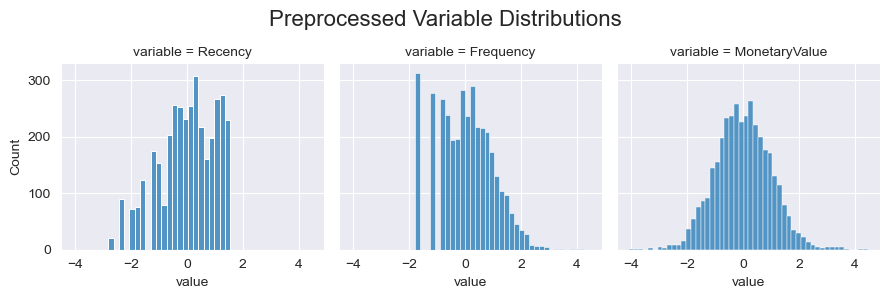

In [16]:
df_log = np.log(df_features)

scaler = StandardScaler()
scaler.fit(df_log)

df_normalized = scaler.transform(df_log)

df_processed = pd.DataFrame(
    data=df_normalized, index=df_features.index, columns=df_features.columns
)

g = sns.FacetGrid(df_processed.melt(), col="variable")
g.map(sns.histplot, "value")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Preprocessed Variable Distributions", fontsize=16)
plt.show()

## 4. Choosing the Number of Clusters

The next step is to fit a variable number of clusters and plot each cluster's sum-of-squared errors (SSE). The Elbow Method helps determine the optimal number of clusters (k) by plotting the Sum of Squared Errors (SSE) for different values of k.
The goal is to identify the point (“elbow”) where adding more clusters yields diminishing improvements.

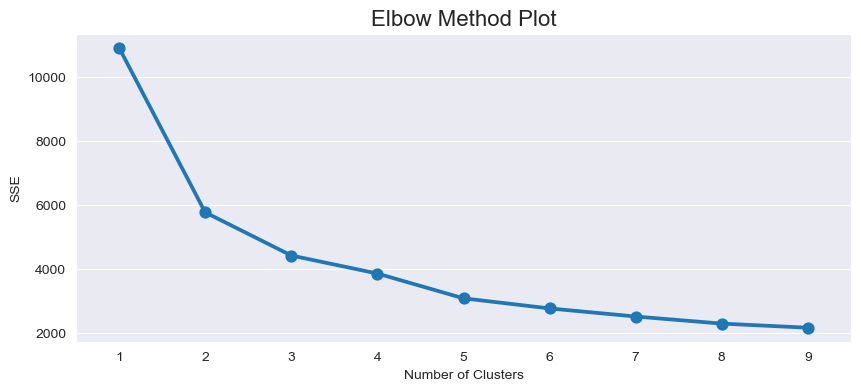

In [21]:
max_clusters = 10
sse = {}

for k in range(1, max_clusters):
    # Initialize KMeans with k clusters
    kmeans = KMeans(n_clusters=k, random_state=1)
    # Fit KMeans on the normalized dataset
    kmeans.fit(df_processed)
    # Assign sum of squared distances to k element of dictionary
    sse[k] = kmeans.inertia_

plt.figure(figsize=(10, 4))
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.title("Elbow Method Plot", fontsize=16)  # Add a title to the plot
plt.xlabel("Number of Clusters")  # Add x-axis label
plt.ylabel("SSE")  # Add y-axis label
plt.show()

## 5. Applying K-Means Clustering
Once the optimal number of clusters is chosen (in this example, k=3), the K-Means model is fitted to the preprocessed dataset. Each customer is then assigned a cluster label.

[`KMeans()`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) from `sklearn.cluster` with `k` clusters is then fit to the processed data, and the cluster labels are extracted and assigned back to the original data. This allows to inspect raw data by cluster in later steps.

In [24]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=1) 

kmeans.fit(df_processed)

cluster_labels = kmeans.labels_
df_clustered = df.assign(Cluster=cluster_labels)

df_clustered

,CustomerID,Recency,Frequency,MonetaryValue,Cluster
0,12747,3,25,948.70,1
1,12748,1,888,7046.16,1
2,12749,4,37,813.45,1
3,12820,4,17,268.02,1
4,12822,71,9,146.15,2
...,...,...,...,...,...
3638,18280,278,2,38.70,0
3639,18281,181,2,31.80,0
3640,18282,8,2,30.70,0
3641,18283,4,152,432.93,1


## 6. Inspecting the Clusters
### a. Visualizing the Raw Values by Cluster
The next step is to analyze the unprocessed data by cluster. We begin by checking how customers are distributed across clusters. The `pandas` method [`DataFrame.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html), combined with the [`.size()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.size.html) method, returns the total number of rows per `Cluster`.

In [27]:
df_sizes = df_clustered.groupby(["Cluster"], as_index=False).size()
df_sizes

,Cluster,size
0,0,1183
1,1,884
2,2,1576


Next, the mean values per cluster are visualized. The data is grouped again, and this time, the `pandas` method [`.mean()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.mean.html) is used to aggregate the data by cluster and calculate the mean for each variable. Alternatively, the [`.agg()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html) method can also be used to specify specific aggregations for different columns if necessary. Consult the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html) for further information on the types of aggregations possible.

The `seaborn` [`catplot()`](https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot) function visualizes the means per cluster.

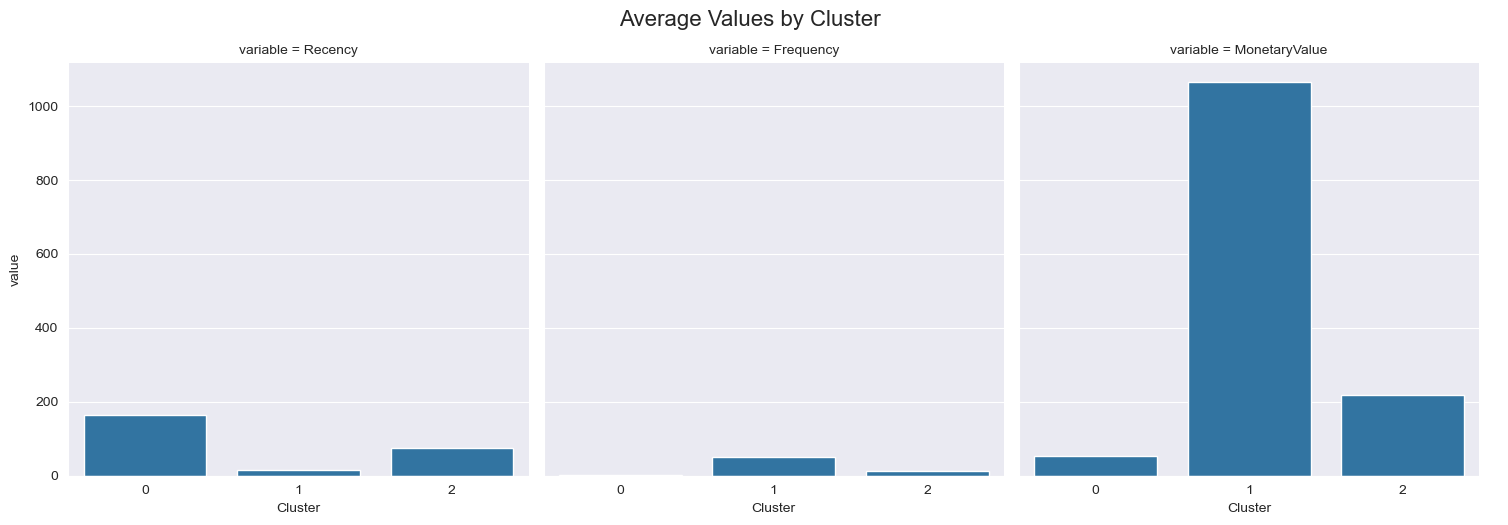

In [29]:
# Calculate the mean of feature columns by cluster
df_means = df_clustered.groupby(["Cluster"])[df_features.columns].mean().reset_index()

# Plot the distributions of the selected variables
sns.catplot(
    data=df_means.melt(id_vars="Cluster"),  # Transform the data to enable plotting
    col="variable",
    x="Cluster",
    y="value",
    kind="bar",
)

plt.suptitle("Average Values by Cluster", y=1.04, fontsize=16)
plt.show()

### 6b. Snake Plot of the Normalized Variables
The next step takes the processed data and visualizes the differences between the clusters using a snake plot. This can be helpful spot trends or key differences that would not be visible with the raw data. The code below uses the following code:
- [`DataFrame.assign()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html) adds the cluster labels to the processed data.
- [`DataFrame.melt()`](https://pandas.pydata.org/pandas-docs/version/1.0.0/reference/api/pandas.DataFrame.melt.html) transforms the data from wide to long format, which makes plotting easier.
- Finally, the `seaborn` [`lineplot()`](https://seaborn.pydata.org/generated/seaborn.lineplot.html) function is used to plot three lines, one for each cluster.

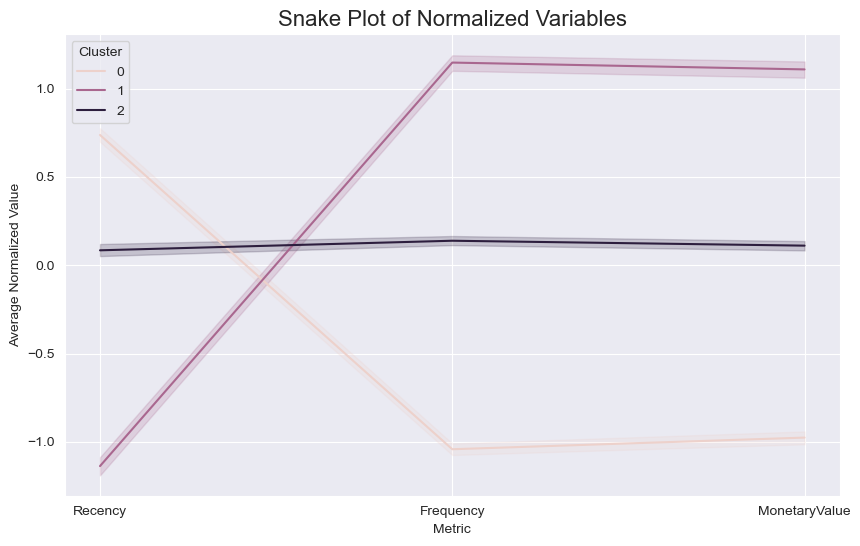

In [32]:
df_processed_clustered = df_processed.assign(Cluster=cluster_labels)
df_processed_melt = pd.melt(
    df_processed_clustered.reset_index(),
    # Assign the cluster labelss as the ID
    id_vars=['Cluster'],
    # Assign clustering variables as values
    value_vars=df_features.columns,
    var_name="Metric",
    value_name="Value",
)

plt.figure(figsize=(10, 6))
plt.title('Snake Plot of Normalized Variables', fontsize=16)
plt.xlabel('Metric')
plt.ylabel('Average Normalized Value')
sns.lineplot(data=df_processed_melt, x='Metric', y='Value', hue='Cluster')
plt.show()

### 6c. Heatmap of Relative Feature Importances
Another technique to help visualize how each segment is distinct is to plot the relative importance. The code below achieves this by doing the following:
- First, it calculates the average values for each cluster.
- Next, it calculates the average values for the total population.
- It then divides the cluster averages by the population averages and subtracts one.

This provides a relative importance score for each of the different features used for clustering. The `seaborn` [`heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) function plots these relative importances on a red to blue color scale to help visualize the relative importance of each attribute to the segments.

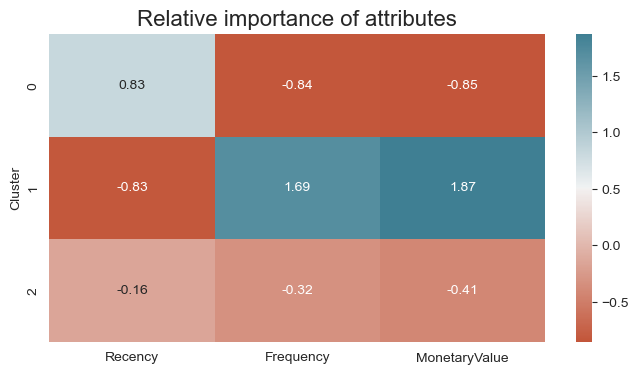

In [34]:
cluster_avg = df_clustered.groupby(["Cluster"])[columns_for_clustering].mean()
population_avg = df[columns_for_clustering].mean()
relative_imp = cluster_avg / population_avg - 1
plt.figure(figsize=(8, 4))
plt.title("Relative importance of attributes", fontsize=16)
sns.heatmap(data=relative_imp, annot=True, fmt=".2f", cmap=sns.diverging_palette(20, 220, as_cmap=True))
plt.show()

This project successfully segments customers into distinct groups based on their purchasing patterns using K-Means clustering.
Through visual tools such as snake plots and heatmaps, we can clearly identify the behavioral traits of each customer group — insights that can guide targeted marketing, loyalty programs, and customer retention initiatives.

Further improvements could include:

Testing other clustering algorithms (e.g., Hierarchical or DBSCAN)
Incorporating demographic or engagement variables
Evaluating stability of clusters over time

This analysis provides a foundation for data-driven customer relationship management and demonstrates how machine learning can uncover actionable business insights.